## **Machine Learning Aplicado a las Finanzas** 🚀
### **HW Sesión 9: Boosting — Gradient Boosting, XGBoost/LightGBM y Riesgo de Modelo**

Profesor:  Andrés C. Medina Sanhueza

Senior Data Scientist Engineer

anmedinas@gmail.com

Alumno Alejandro Alvear Sepulveda
alvear.sepulveda@gmail.com

---

### Consideraciones Previas

* Tarea es **Individual**
* Fecha de Entrega: **Jueves 30 Jul 23:59** (cualquier commit posterior descontará puntos)
* El notebook debe correr de arriba abajo sin errores (`Kernel → Restart & Run All`)
* No se admiten `pass` pendientes ni celdas vacías donde se espera código
* **Regla de oro:** si se detecta data leakage en alguna solución (uso de información futura en la construcción de features, en el ajuste del pseudo-residuo, o en la partición train/val/test), esa parte se evalúa con nota 1.0
* Deben crear una rama nueva en su repositorio `feat/hw07` y trabajar la tarea en esa rama. El notebook debe quedar en la carpeta `hw/`
* **Archivo a entregar:** URL del repositorio GitHub enviada a `anmedinas@gmail.com`

In [12]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import Markdown, display
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
)
from sklearn.linear_model import Ridge
from sklearn.datasets import make_classification
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, train_test_split
from sklearn.metrics import roc_auc_score, mean_squared_error
from scipy.special import expit
from scipy.stats import spearmanr

import xgboost as xgb
import lightgbm as lgb

sns.set_theme(style="darkgrid")
warnings.filterwarnings("ignore")
np.random.seed(42)
pd.set_option("display.float_format", "{:.4f}".format)

RANDOM_STATE = 42

### Reproducibilidad

El notebook usa `data/raw/hw06_aapl_market.csv`, una copia local de AAPL para
2015–2023. Esto evita depender de la red y conserva exactamente la misma muestra en
cada ejecución. Las versiones utilizadas están registradas en
`requirements-hw07.txt`; para reconstruir el ambiente se ejecuta
`python -m pip install -r requirements-hw07.txt` desde la raíz del repositorio.

## Resumen ejecutivo

- La implementación manual reprodujo el MSE de sklearn (0.0118) y quedó a 0.0396 de
  XGBoost en AUC, dentro de la tolerancia exigida.
- Early stopping superó al grid search en test: AUC 0.7516 para XGBoost y 0.7117 para
  LightGBM.
- `mom_10` fue la variable con mayor discrepancia Weight–Gain; con 30% de ruido,
  boosting resultó ligeramente más inestable que Random Forest.
- En el selloff de 2018, los tres modelos de árboles quedaron acotados por el máximo
  de train; Ridge extrapoló y obtuvo el menor RMSE (0.0236).
- Una restricción monótona con signo incorrecto redujo el AUC a 0.5000, frente a
  0.8408 con la dirección correcta.

---
## Datos Base

Reutilizamos el problema de **eventos de cola** de la sesión 9 (retorno del día siguiente en el percentil 5 más bajo), con los mismos 7 features. A diferencia de la sesión, aquí agregamos un split de **validación** explícito (70/15/15) porque varias partes de esta tarea (2.1, 2.2) requieren *early stopping*, que necesita un set de validación separado del set de test.

In [2]:
TICKER = "AAPL"

# Se reutiliza la copia local obtenida para HW06. Así el notebook es reproducible
# y no depende de la red ni de cambios futuros en Yahoo Finance.
candidate_paths = [
    Path("data/raw/hw06_aapl_market.csv"),
    Path("../data/raw/hw06_aapl_market.csv"),
]
data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "No se encontró data/raw/hw06_aapl_market.csv. Ejecuta el notebook desde "
        "la raíz del repositorio o conserva el archivo dentro de data/raw/."
    )

raw = pd.read_csv(data_path, parse_dates=["Date"], index_col="Date").sort_index()
required_columns = {"Close", "Volume"}
missing_columns = required_columns.difference(raw.columns)
if missing_columns:
    raise ValueError(f"Faltan columnas requeridas: {sorted(missing_columns)}")

close = raw["Close"]
ret = close.pct_change()

feat = pd.DataFrame(index=raw.index)
feat["ret_lag1"] = ret.shift(1)
feat["ret_lag2"] = ret.shift(2)
feat["ret_lag5"] = ret.shift(1).rolling(5).sum()
feat["vol_20"] = ret.shift(1).rolling(20).std() * np.sqrt(252)
feat["mom_10"] = close.shift(1) / close.shift(11) - 1
delta = close.diff()
gain = delta.clip(lower=0).shift(1).rolling(14).mean()
loss = (-delta.clip(upper=0)).shift(1).rolling(14).mean()
feat["rsi_14"] = 100 - 100 / (1 + gain / loss.replace(0, np.nan))
feat["vol_chg"] = raw["Volume"].pct_change().shift(1)

# El umbral se estima solo con retornos observados dentro de train (70%).
# Esto evita que la definición de target use la distribución de val/test.
feature_columns = ["ret_lag1", "ret_lag2", "ret_lag5", "vol_20", "mom_10", "rsi_14", "vol_chg"]
model_data = feat.assign(next_return=ret.shift(-1)).dropna(subset=feature_columns + ["next_return"])
split_tr = int(len(model_data) * 0.70)
split_va = int(len(model_data) * 0.85)
tail_threshold = model_data["next_return"].iloc[:split_tr].quantile(0.05)
model_data["target"] = (model_data["next_return"] <= tail_threshold).astype(int)

FEATURES = feature_columns
X = model_data[FEATURES].to_numpy()
y = model_data["target"].to_numpy()

X_train, X_val, X_test = X[:split_tr], X[split_tr:split_va], X[split_va:]
y_train, y_val, y_test = y[:split_tr], y[split_tr:split_va], y[split_va:]

print(f"Fuente local: {data_path.resolve()}")
print(f"{TICKER}: {model_data.shape[0]} obs | {len(FEATURES)} features")
print(f"Train: {len(y_train)} obs | Val: {len(y_val)} obs | Test: {len(y_test)} obs")
print(f"Umbral de cola estimado en train: {tail_threshold:.4%}")
print(f"Tasa de eventos — train: {y_train.mean():.2%} | val: {y_val.mean():.2%} | test: {y_test.mean():.2%}")

Fuente local: /Users/alejandroalvear/Proyectos/tarea04/data/raw/hw06_aapl_market.csv
AAPL: 2242 obs | 7 features
Train: 1569 obs | Val: 336 obs | Test: 337 obs
Umbral de cola estimado en train: -2.7106%
Tasa de eventos — train: 5.04% | val: 5.95% | test: 4.45%


---
## Parte 1 — Gradient Boosting desde Cero: Pseudo-Residuos por Función de Pérdida *(25 pts)*

### Contexto

En la sesión 9 vimos el algoritmo de Friedman (2001): dado $F_0(x)$ (una constante), en cada ronda $m$ se calcula el **pseudo-residuo** (el gradiente negativo de la pérdida respecto a las predicciones actuales),

$$r_{im} = -\left[\frac{\partial L(y_i, F(x_i))}{\partial F(x_i)}\right]_{F=F_{m-1}}$$

se ajusta un árbol débil $h_m$ a esos pseudo-residuos, y se actualiza $F_m(x) = F_{m-1}(x) + \nu \cdot h_m(x)$. En clase implementamos esto **solo para pérdida cuadrática** (regresión), donde el pseudo-residuo es simplemente el residuo ordinario $y_i - F_{m-1}(x_i)$. Esta parte te pide completar el algoritmo general: implementarlo para MSE (1.1) y luego derivar y programar el caso de **log-loss** para clasificación binaria (1.2), que es exactamente lo que XGBoost/LightGBM hacen internamente (con una aproximación de segundo orden que aquí no exigimos replicar).

### 1.1 — Gradient Boosting para Regresión (MSE) *(13 pts)*

**Requisitos:**
1. Implementa `gradient_boosting_fit` y `gradient_boosting_predict` completando los TODOs de la celda siguiente
2. Verifica tu implementación sobre la misma función seno con ruido de la sesión 9 (la celda de verificación ya genera esos datos): compara el MSE final de tu modelo manual contra `GradientBoostingRegressor` de sklearn con los mismos `n_estimators`, `learning_rate` y `max_depth`
3. Grafica ambas curvas de ajuste (manual vs sklearn) superpuestas sobre los datos, y el MSE por ronda de tu implementación manual
4. Tu implementación debe alcanzar un MSE final dentro de un 15% del de sklearn (ambos algoritmos deberían converger a soluciones muy similares, no idénticas — sklearn usa optimizaciones internas adicionales)

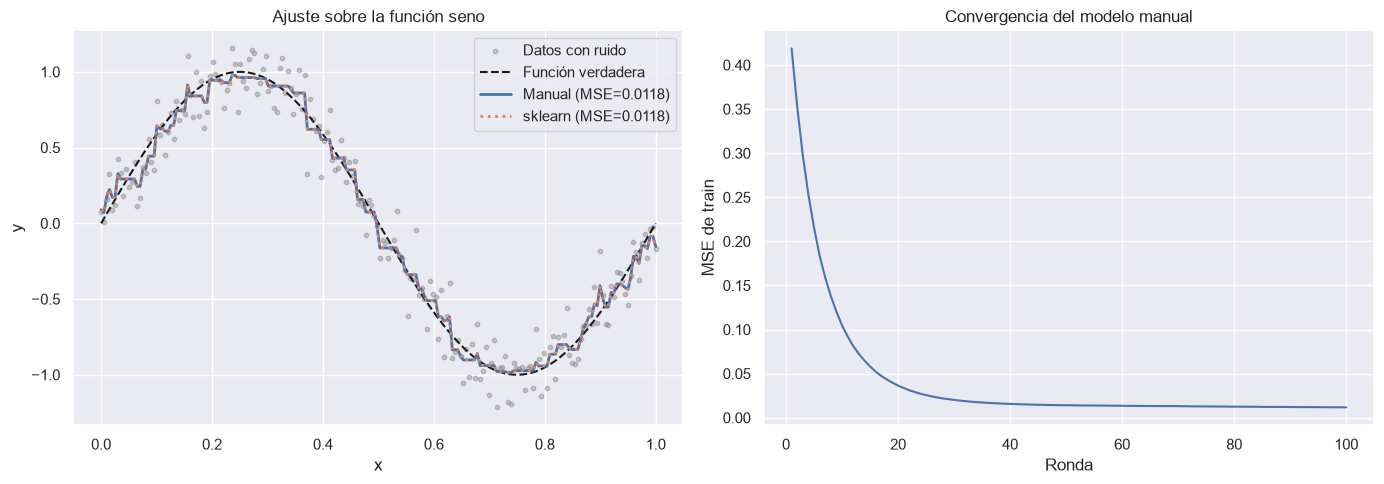

MSE manual: 0.0118
MSE sklearn: 0.0118
Diferencia relativa: 0.00%


In [3]:
def gradient_boosting_fit(X, y, n_estimators=100, learning_rate=0.1,
                          max_depth=2, random_state=42):
    """Ajusta Gradient Boosting de regresión con pérdida cuadrática."""
    X = np.asarray(X)
    y = np.asarray(y, dtype=float)
    if len(X) != len(y):
        raise ValueError("X e y deben tener igual número de observaciones")

    F0 = float(np.mean(y))
    current_prediction = np.full(y.shape, F0, dtype=float)
    trees = []

    rng = np.random.default_rng(random_state)
    for _ in range(n_estimators):
        pseudo_residual = y - current_prediction
        tree = DecisionTreeRegressor(
            max_depth=max_depth,
            random_state=int(rng.integers(0, np.iinfo(np.int32).max)),
        )
        tree.fit(X, pseudo_residual)
        current_prediction += learning_rate * tree.predict(X)
        trees.append(tree)

    return F0, trees


def gradient_boosting_predict(F0, trees, X, learning_rate=0.1):
    """Obtiene la predicción aditiva F0 + nu * suma(h_m(X))."""
    prediction = np.full(len(X), float(F0), dtype=float)
    for tree in trees:
        prediction += learning_rate * tree.predict(X)
    return prediction


# === Verificación ===
np.random.seed(42)
x_gb = np.linspace(0, 1, 200).reshape(-1, 1)
y_true_gb = np.sin(2 * np.pi * x_gb).ravel()
y_gb = y_true_gb + np.random.normal(0, 0.15, len(x_gb))

N_EST, LR, DEPTH = 100, 0.1, 2
F0_manual, trees_manual = gradient_boosting_fit(
    x_gb, y_gb, n_estimators=N_EST, learning_rate=LR,
    max_depth=DEPTH, random_state=42
)
pred_manual = gradient_boosting_predict(F0_manual, trees_manual, x_gb, LR)

gbr_ref = GradientBoostingRegressor(
    n_estimators=N_EST, learning_rate=LR, max_depth=DEPTH, random_state=42
).fit(x_gb, y_gb)
pred_ref = gbr_ref.predict(x_gb)

mse_manual = mean_squared_error(y_gb, pred_manual)
mse_ref = mean_squared_error(y_gb, pred_ref)
mse_relative_difference = abs(mse_manual - mse_ref) / mse_ref

staged_mse = [
    mean_squared_error(
        y_gb,
        gradient_boosting_predict(F0_manual, trees_manual[:round_number], x_gb, LR),
    )
    for round_number in range(1, N_EST + 1)
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(x_gb.ravel(), y_gb, s=10, color="gray", alpha=0.4, label="Datos con ruido")
axes[0].plot(x_gb.ravel(), y_true_gb, "k--", lw=1.5, label="Función verdadera")
axes[0].plot(x_gb.ravel(), pred_manual, lw=2, label=f"Manual (MSE={mse_manual:.4f})")
axes[0].plot(x_gb.ravel(), pred_ref, lw=2, ls=":", label=f"sklearn (MSE={mse_ref:.4f})")
axes[0].set(title="Ajuste sobre la función seno", xlabel="x", ylabel="y")
axes[0].legend()
axes[1].plot(range(1, N_EST + 1), staged_mse)
axes[1].set(title="Convergencia del modelo manual", xlabel="Ronda", ylabel="MSE de train")
plt.tight_layout()
plt.show()

print(f"MSE manual: {mse_manual:.4f}")
print(f"MSE sklearn: {mse_ref:.4f}")
print(f"Diferencia relativa: {mse_relative_difference:.2%}")
assert mse_relative_difference <= 0.15, "El MSE manual difiere más de 15% respecto de sklearn"

### 1.2 — Extensión a Clasificación Binaria: Pseudo-Residuo de Log-Loss *(12 pts)*

Para clasificación binaria con log-loss, $F(x)$ representa el **log-odds** (margen, antes de la sigmoide) y la pérdida es $L(y, F) = -[y\log p + (1-y)\log(1-p)]$ con $p = \sigma(F) = 1/(1+e^{-F})$. Deberás derivar (a mano, en la celda de texto siguiente) el pseudo-residuo $r_{im} = -\partial L/\partial F$ para esta pérdida, y usarlo para completar la implementación.

**Requisitos:**
1. En la celda markdown de abajo, muestra el desarrollo de $-\partial L(y,F)/\partial F$ y confirma que se reduce a $y - \sigma(F)$
2. Implementa `gradient_boosting_logloss_fit` y `gradient_boosting_logloss_predict_proba`, reutilizando la misma estructura de 1.1 pero con: (a) $F_0 = \text{logit}(\bar{y})$ (log-odds de la tasa base) en vez de la media, y (b) el pseudo-residuo derivado arriba en vez del residuo ordinario
3. Verifica tu implementación sobre el dataset sintético que genera la celda de verificación (`make_classification`, moderadamente balanceado — a propósito, para no mezclar este chequeo con el problema de desbalance severo de la Parte 3), comparando el AUC de test contra `xgb.XGBClassifier` con los mismos `n_estimators`/`learning_rate`/`max_depth`
4. Tu AUC manual debe quedar dentro de 0.05 del AUC de XGBoost (tu versión es una aproximación de primer orden sin regularización — XGBoost usa una aproximación de segundo orden con $\lambda$, así que una diferencia pequeña es esperable, no un error)

**Derivación:**

Sea $p=\sigma(F)$. Aplicando la regla de la cadena y usando
$\sigma'(F)=p(1-p)$:

$$
\frac{\partial L}{\partial F}
=-\left[y\frac{1}{p}\frac{\partial p}{\partial F}
+(1-y)\frac{-1}{1-p}\frac{\partial p}{\partial F}\right]
$$

$$
=-\left[y(1-p)-(1-y)p\right]
=p-y.
$$

Por lo tanto,

$$
-\frac{\partial L}{\partial F}=y-p=y-\sigma(F),
$$

y el pseudo-residuo de la ronda $m$ es
$r_{im}=y_i-\sigma(F_{m-1}(x_i))$.

In [4]:
def gradient_boosting_logloss_fit(X, y, n_estimators=100, learning_rate=0.1,
                                  max_depth=2, random_state=42):
    """Ajusta boosting binario de primer orden usando pseudo-residuos logísticos."""
    X = np.asarray(X)
    y = np.asarray(y, dtype=float)
    if not np.isin(y, [0, 1]).all():
        raise ValueError("y debe contener solamente 0 y 1")

    eps = np.finfo(float).eps
    base_rate = np.clip(y.mean(), eps, 1 - eps)
    F0 = float(np.log(base_rate / (1 - base_rate)))
    margin = np.full(y.shape, F0, dtype=float)
    trees = []
    rng = np.random.default_rng(random_state)

    for _ in range(n_estimators):
        pseudo_residual = y - expit(margin)
        tree = DecisionTreeRegressor(
            max_depth=max_depth,
            random_state=int(rng.integers(0, np.iinfo(np.int32).max)),
        )
        tree.fit(X, pseudo_residual)
        margin += learning_rate * tree.predict(X)
        trees.append(tree)

    return F0, trees


def gradient_boosting_logloss_predict_proba(F0, trees, X, learning_rate=0.1):
    """Devuelve P(y=1|X) aplicando sigmoide al margen aditivo."""
    margin = np.full(len(X), float(F0), dtype=float)
    for tree in trees:
        margin += learning_rate * tree.predict(X)
    return expit(margin)


# === Verificación ===
X_synth, y_synth = make_classification(
    n_samples=2000, n_features=8, n_informative=5,
    weights=[0.7, 0.3], class_sep=1.0, random_state=42
)
X_synth_tr, X_synth_te, y_synth_tr, y_synth_te = train_test_split(
    X_synth, y_synth, test_size=0.30, stratify=y_synth, random_state=42
)

N_EST2, LR2, DEPTH2 = 100, 0.1, 2
F0_cls, trees_cls = gradient_boosting_logloss_fit(
    X_synth_tr, y_synth_tr, n_estimators=N_EST2,
    learning_rate=LR2, max_depth=DEPTH2, random_state=42
)
proba_manual_cls = gradient_boosting_logloss_predict_proba(
    F0_cls, trees_cls, X_synth_te, learning_rate=LR2
)
auc_manual_cls = roc_auc_score(y_synth_te, proba_manual_cls)

xgb_ref_cls = xgb.XGBClassifier(
    n_estimators=N_EST2, learning_rate=LR2, max_depth=DEPTH2,
    reg_lambda=0.0, eval_metric="auc", random_state=42
).fit(X_synth_tr, y_synth_tr)
auc_ref_cls = roc_auc_score(y_synth_te, xgb_ref_cls.predict_proba(X_synth_te)[:, 1])
auc_absolute_difference = abs(auc_manual_cls - auc_ref_cls)

print(f"AUC manual: {auc_manual_cls:.4f}")
print(f"AUC XGBoost: {auc_ref_cls:.4f}")
print(f"Diferencia absoluta: {auc_absolute_difference:.4f}")
assert auc_absolute_difference <= 0.05, "La diferencia de AUC supera 0.05"

AUC manual: 0.9221
AUC XGBoost: 0.9617
Diferencia absoluta: 0.0396


### Preguntas de Interpretación — Parte 1

**a)** En MSE, el pseudo-residuo es la diferencia en la escala original,
$y-F(x)$; en log-loss es la diferencia entre la etiqueta y la probabilidad actual,
$y-\sigma(F(x))$. Ambos reciben el nombre de residuo porque representan el gradiente
negativo de la pérdida: indican la dirección local en que debe corregirse la predicción
para reducir el error.

**b)** La implementación manual obtuvo MSE 0.0118, igual al 0.0118 de sklearn a
cuatro decimales (diferencia relativa 0.00%); en clasificación obtuvo AUC 0.9221 frente
a 0.9617 de XGBoost, una diferencia absoluta de 0.0396. La brecha de clasificación se
debe a que la versión manual ajusta solo el gradiente de primer orden con árboles CART,
mientras XGBoost usa gradiente y Hessiano, pondera las hojas y dispone de mecanismos
adicionales de regularización y construcción del árbol.

**c)** Para usar Huber se mantendría la estructura aditiva, pero se cambiarían
$F_0$ y el cálculo del pseudo-residuo dentro de `fit`: el gradiente es lineal para
errores pequeños y queda truncado en $\pm\delta$ para errores grandes. La función de
predicción seguiría sumando árboles y ya no aplicaría sigmoide, porque Huber es una
pérdida de regresión sobre la escala original.

---
## Parte 2 — Hiperparámetros, Overfitting y Validación Walk-Forward *(25 pts)*

### Contexto

La sesión 9 mostró que, a diferencia de Random Forest, boosting **sí puede sobreajustar** con más rondas — el AUC de validación forma una "U invertida" en función de `n_estimators`, lo que hace obligatorio el *early stopping*. También vimos que LightGBM crece los árboles *leaf-wise* (más agresivo, converge más rápido pero sobreajusta más fácil) mientras XGBoost crece *level-wise* por defecto. Esta parte te pide reproducir ambos diagnósticos con tus propios datos (`X_train, X_val, X_test` de la sección "Datos Base") y comparar XGBoost vs LightGBM directamente.

### 2.1 — Overfitting sin Early Stopping: XGBoost vs LightGBM *(10 pts)*

**Requisitos:**
1. Entrena un `xgb.XGBClassifier` y un `lgb.LGBMClassifier`, cada uno con `n_estimators=500` y **sin** `early_stopping_rounds`, sobre `X_train, y_train`
2. Para cada modelo, calcula el AUC de train y de validación (`X_val, y_val`) usando `iteration_range` (XGBoost) o el parámetro equivalente de predicción parcial de LightGBM, en incrementos de al menos 20 rondas
3. Grafica ambas curvas (train/val AUC vs ronda) en dos paneles, uno por modelo, marcando la ronda óptima de validación en cada uno
4. Reporta la ronda óptima de cada modelo y compara

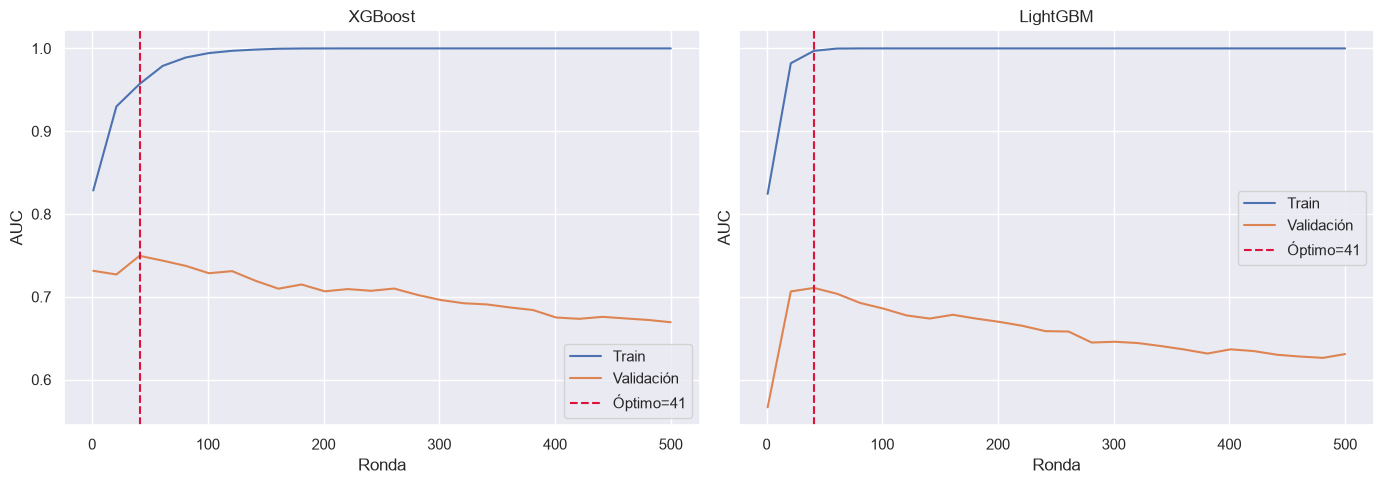

Rondas óptimas de validación: {'XGBoost': 41, 'LightGBM': 41}


In [5]:
# Modelos deliberadamente sin early stopping.
xgb_of = xgb.XGBClassifier(
    n_estimators=500, learning_rate=0.1, max_depth=4,
    eval_metric="auc", random_state=RANDOM_STATE, n_jobs=-1
).fit(X_train, y_train)

lgb_of = lgb.LGBMClassifier(
    n_estimators=500, learning_rate=0.1, num_leaves=15,
    random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1
).fit(X_train, y_train)

rounds = sorted(set(list(range(1, 501, 20)) + [500]))

curves = {
    "XGBoost": {"train": [], "val": []},
    "LightGBM": {"train": [], "val": []},
}
for round_number in rounds:
    xgb_train_probability = xgb_of.predict_proba(
        X_train, iteration_range=(0, round_number)
    )[:, 1]
    xgb_val_probability = xgb_of.predict_proba(
        X_val, iteration_range=(0, round_number)
    )[:, 1]
    lgb_train_probability = lgb_of.predict_proba(X_train, num_iteration=round_number)[:, 1]
    lgb_val_probability = lgb_of.predict_proba(X_val, num_iteration=round_number)[:, 1]

    curves["XGBoost"]["train"].append(roc_auc_score(y_train, xgb_train_probability))
    curves["XGBoost"]["val"].append(roc_auc_score(y_val, xgb_val_probability))
    curves["LightGBM"]["train"].append(roc_auc_score(y_train, lgb_train_probability))
    curves["LightGBM"]["val"].append(roc_auc_score(y_val, lgb_val_probability))

optimal_rounds = {}
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for axis, model_name in zip(axes, ["XGBoost", "LightGBM"]):
    validation_auc = np.asarray(curves[model_name]["val"])
    optimal_index = int(np.argmax(validation_auc))
    optimal_round = rounds[optimal_index]
    optimal_rounds[model_name] = optimal_round
    axis.plot(rounds, curves[model_name]["train"], label="Train")
    axis.plot(rounds, validation_auc, label="Validación")
    axis.axvline(optimal_round, color="crimson", ls="--", label=f"Óptimo={optimal_round}")
    axis.set(title=model_name, xlabel="Ronda", ylabel="AUC")
    axis.legend()
plt.tight_layout()
plt.show()

print("Rondas óptimas de validación:", optimal_rounds)

### 2.2 — Grid Search Walk-Forward: Selección de Hiperparámetros vs Early Stopping *(15 pts)*

**Requisitos:**
1. Construye un `Pipeline` (`SimpleImputer` + `StandardScaler` + `clf`) para XGBoost y otro para LightGBM
2. Define un grid de hiperparámetros para cada uno (mínimo 3 valores por hiperparámetro, mínimo 2 hiperparámetros): para XGBoost usa `max_depth` y `learning_rate`; para LightGBM usa `num_leaves` y `learning_rate`
3. Ejecuta `GridSearchCV` con `TimeSeriesSplit(n_splits=5)` sobre `X_train_full = vstack([X_train, X_val])` (concatenando train+val, igual que en la sesión 9), y reporta el mejor score de CV y los mejores hiperparámetros de cada modelo
4. Por separado, entrena cada modelo con *early stopping* (usando `X_val, y_val` como set de validación) y compara el AUC de **test** de ambos enfoques (grid search + refit vs early stopping) en una tabla
5. En las preguntas de interpretación, discute cuál enfoque preferirías para un modelo que se reentrena diariamente vs uno que se reentrena trimestralmente (la sesión 9 plantea esta distinción explícitamente)

In [6]:
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])
tscv = TimeSeriesSplit(n_splits=5)

pipe_xgb = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", xgb.XGBClassifier(
        n_estimators=300, eval_metric="auc", random_state=RANDOM_STATE, n_jobs=-1
    )),
])
param_grid_xgb = {
    "clf__max_depth": [2, 3, 4],
    "clf__learning_rate": [0.03, 0.10, 0.30],
}
grid_xgb = GridSearchCV(
    pipe_xgb, param_grid_xgb, scoring="roc_auc", cv=tscv,
    n_jobs=-1, refit=True
).fit(X_train_full, y_train_full)

pipe_lgb = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("clf", lgb.LGBMClassifier(
        n_estimators=300, verbosity=-1, random_state=RANDOM_STATE, n_jobs=-1
    )),
])
param_grid_lgb = {
    "clf__num_leaves": [7, 15, 31],
    "clf__learning_rate": [0.03, 0.10, 0.30],
}
grid_lgb = GridSearchCV(
    pipe_lgb, param_grid_lgb, scoring="roc_auc", cv=tscv,
    n_jobs=-1, refit=True
).fit(X_train_full, y_train_full)

xgb_es = xgb.XGBClassifier(
    n_estimators=2000, learning_rate=0.03, max_depth=3,
    eval_metric="auc", early_stopping_rounds=50,
    random_state=RANDOM_STATE, n_jobs=-1
).fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

lgb_es = lgb.LGBMClassifier(
    n_estimators=2000, learning_rate=0.03, num_leaves=15,
    random_state=RANDOM_STATE, verbosity=-1, n_jobs=-1
).fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)], eval_metric="auc",
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

comparison_22 = pd.DataFrame([
    {
        "modelo": "XGBoost", "enfoque": "Grid search + refit",
        "AUC_test": roc_auc_score(y_test, grid_xgb.predict_proba(X_test)[:, 1]),
    },
    {
        "modelo": "XGBoost", "enfoque": "Early stopping",
        "AUC_test": roc_auc_score(y_test, xgb_es.predict_proba(X_test)[:, 1]),
    },
    {
        "modelo": "LightGBM", "enfoque": "Grid search + refit",
        "AUC_test": roc_auc_score(y_test, grid_lgb.predict_proba(X_test)[:, 1]),
    },
    {
        "modelo": "LightGBM", "enfoque": "Early stopping",
        "AUC_test": roc_auc_score(
            y_test, lgb_es.predict_proba(X_test, num_iteration=lgb_es.best_iteration_)[:, 1]
        ),
    },
])

print(f"XGBoost — mejor CV: {grid_xgb.best_score_:.4f} | {grid_xgb.best_params_}")
print(f"LightGBM — mejor CV: {grid_lgb.best_score_:.4f} | {grid_lgb.best_params_}")
display(comparison_22)

XGBoost — mejor CV: 0.6361 | {'clf__learning_rate': 0.03, 'clf__max_depth': 2}
LightGBM — mejor CV: 0.6403 | {'clf__learning_rate': 0.3, 'clf__num_leaves': 15}


,modelo,enfoque,AUC_test
0,XGBoost,Grid search + refit,0.6977
1,XGBoost,Early stopping,0.7516
2,LightGBM,Grid search + refit,0.6857
3,LightGBM,Early stopping,0.7117


### Preguntas de Interpretación — Parte 2

**a)** Ambos modelos alcanzaron su mejor AUC de validación en la ronda 41, por lo que
LightGBM no se detuvo antes en este experimento. Esto puede explicarse por el límite
moderado `num_leaves=15`, la profundidad 4 de XGBoost y la grilla de evaluación cada
20 rondas, que no distingue óptimos cercanos dentro del mismo intervalo.

**b)** Early stopping ganó en test para ambos modelos: XGBoost alcanzó AUC 0.7516
frente a 0.6977 del grid search (+0.0539), y LightGBM 0.7117 frente a 0.6857 (+0.0260).
En esta muestra el costo computacional adicional del grid search no se justifica,
porque produjo un desempeño menor incluso después del refit.

**c)** Para reentrenamiento diario elegiría *early stopping*, porque adapta de forma
económica el número de rondas a cada nueva ventana. Para una revisión trimestral usaría
grid search *walk-forward* y luego *early stopping* dentro de la configuración elegida,
porque hay más tiempo para validar hiperparámetros respetando el orden temporal.

---
## Parte 3 — Feature Importance y Sensibilidad a Ruido: Boosting vs Bagging *(25 pts)*

### Contexto

XGBoost expone tres métricas de importancia (`Weight`, `Gain`, `Cover`) que pueden rankear features de forma distinta — la sesión 9 mostró que esto revela información que una sola métrica esconde. También vimos que, en teoría, boosting es más sensible a ruido de etiquetas que bagging porque ajusta secuencialmente al residuo. Esta parte te pide cuantificar ambos fenómenos con más rigor del que se hizo en clase.

### 3.1 — Weight vs Gain vs Cover: Cuantificando el Desacuerdo *(13 pts)*

**Requisitos:**
1. Entrena un `xgb.XGBClassifier` sobre `X_train, y_train` (usa hiperparámetros razonables, con `early_stopping_rounds` sobre `X_val, y_val`)
2. Extrae las tres métricas de importancia (`weight`, `gain`, `cover`) y constrúyelas en un DataFrame indexado por `FEATURES`
3. Calcula la correlación de Spearman **entre cada par** de las tres métricas (Weight-Gain, Weight-Cover, Gain-Cover) — 3 números
4. Identifica el feature con **mayor discrepancia** entre su ranking de `Weight` y su ranking de `Gain` (mayor diferencia absoluta de rangos), y en las preguntas de interpretación explica el mecanismo (¿se usa poco pero aporta mucho, o se usa mucho pero aporta poco?)

In [7]:
xgb_imp = xgb.XGBClassifier(
    n_estimators=1000, learning_rate=0.03, max_depth=3,
    eval_metric="auc", early_stopping_rounds=50,
    random_state=RANDOM_STATE, n_jobs=-1
).fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=False)

booster = xgb_imp.get_booster()
importance_types = ["weight", "gain", "cover"]
importance_data = {}
for importance_type in importance_types:
    raw_importance = booster.get_score(importance_type=importance_type)
    importance_data[importance_type] = [
        raw_importance.get(f"f{feature_index}", 0.0)
        for feature_index in range(len(FEATURES))
    ]

imp_df = pd.DataFrame(importance_data, index=FEATURES)
rank_columns = {}
for importance_type in importance_types:
    rank_columns[f"rank_{importance_type}"] = imp_df[importance_type].rank(
        ascending=False, method="min"
    )
rank_df = pd.DataFrame(rank_columns, index=FEATURES)
imp_df = imp_df.join(rank_df)
imp_df["rank_gap_weight_gain"] = (
    imp_df["rank_weight"] - imp_df["rank_gain"]
).abs()

spearman_pairs = {}
for left, right in [("weight", "gain"), ("weight", "cover"), ("gain", "cover")]:
    correlation, p_value = spearmanr(imp_df[left], imp_df[right])
    spearman_pairs[f"{left}-{right}"] = {"rho": correlation, "p_value": p_value}

most_discrepant_feature = imp_df["rank_gap_weight_gain"].idxmax()
display(imp_df.sort_values("gain", ascending=False))
display(pd.DataFrame(spearman_pairs).T)
print("Mayor discrepancia Weight-Gain:", most_discrepant_feature)

,weight,gain,cover,rank_weight,rank_gain,rank_cover,rank_gap_weight_gain
mom_10,52.0000,13.2083,48.8420,6.0000,1.0000,2.0000,5.0000
vol_20,101.0000,7.6555,50.2987,1.0000,2.0000,1.0000,1.0000
rsi_14,76.0000,4.5624,38.2250,3.0000,3.0000,3.0000,0.0000
vol_chg,90.0000,4.1101,32.4490,2.0000,4.0000,5.0000,2.0000
ret_lag1,60.0000,3.8642,29.1317,5.0000,5.0000,7.0000,0.0000
ret_lag5,34.0000,3.4775,29.4346,7.0000,6.0000,6.0000,1.0000
ret_lag2,63.0000,2.7901,33.0755,4.0000,7.0000,4.0000,3.0000


,rho,p_value
weight-gain,0.2857,0.5345
weight-cover,0.4643,0.2939
gain-cover,0.7143,0.0713


Mayor discrepancia Weight-Gain: mom_10


### 3.2 — Sensibilidad a Ruido de Etiquetas: RF vs XGBoost vs LightGBM, y una Mitigación *(12 pts)*

**Requisitos:**
1. Extiende el experimento de la sesión 9 (contaminación de etiquetas de train) a **tres** modelos: `RandomForestClassifier`, `XGBoost`, `LightGBM`
2. Usa `noise_levels = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]` y al menos 10 semillas por nivel (más que las 8 de la sesión, para una estimación más estable de la desviación estándar)
3. Para cada modelo y nivel de ruido, calcula el **coeficiente de variación** $CV = \text{std}/\text{mean}$ del AUC de test entre semillas — esta es tu métrica cuantitativa de inestabilidad (más alta = más sensible al ruido específico de las etiquetas volteadas)
4. Grafica el CV vs nivel de ruido para los tres modelos en un mismo gráfico
5. **Mitigación:** al nivel de ruido más alto (0.30), reentrena XGBoost y LightGBM con `min_child_weight`/`min_data_in_leaf` y `reg_lambda` aumentados (elige valores y justifica), y verifica si el CV baja frente a la versión sin mitigar, reportando también cuánto AUC promedio se sacrifica

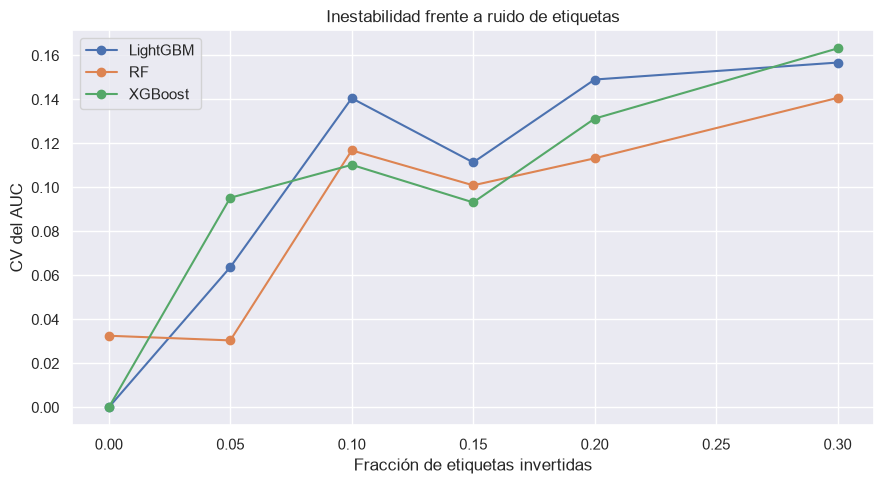

,noise_fraction,modelo,mean_auc,std_auc,cv_auc
0,0.0000,RF,0.6986,0.0227,0.0325
1,0.0000,XGBoost,0.6613,0.0000,0.0000
2,0.0000,LightGBM,0.6041,0.0000,0.0000
3,0.0500,RF,0.6378,0.0194,0.0304
4,0.0500,XGBoost,0.6458,0.0615,0.0953
5,0.0500,LightGBM,0.5920,0.0377,0.0637
6,0.1000,RF,0.6420,0.0750,0.1168
7,0.1000,XGBoost,0.6253,0.0690,0.1103
8,0.1000,LightGBM,0.5711,0.0803,0.1406
9,0.1500,RF,0.6267,0.0633,0.1010


,modelo,CV_base,CV_mitigado,cambio_CV,AUC_base,AUC_mitigado,costo_AUC
0,XGBoost,0.1632,0.2063,0.0431,0.5530,0.5239,0.0292
1,LightGBM,0.1568,0.1526,-0.0042,0.5337,0.5199,0.0138


In [8]:
noise_levels = [0.0, 0.05, 0.10, 0.15, 0.20, 0.30]
n_repeats = 10


def contaminate_labels(labels, noise_fraction, seed):
    rng = np.random.default_rng(seed)
    contaminated = labels.copy()
    n_flip = int(round(noise_fraction * len(labels)))
    if n_flip:
        flip_index = rng.choice(len(labels), size=n_flip, replace=False)
        contaminated[flip_index] = 1 - contaminated[flip_index]
    return contaminated


def noise_models(seed, mitigated=False):
    if mitigated:
        return {
            "XGBoost": xgb.XGBClassifier(
                n_estimators=200, learning_rate=0.05, max_depth=3,
                min_child_weight=20, reg_lambda=20,
                eval_metric="auc", random_state=seed, n_jobs=-1
            ),
            "LightGBM": lgb.LGBMClassifier(
                n_estimators=200, learning_rate=0.05, num_leaves=15,
                min_data_in_leaf=50, reg_lambda=20,
                verbosity=-1, random_state=seed, n_jobs=-1
            ),
        }
    return {
        "RF": RandomForestClassifier(
            n_estimators=200, class_weight="balanced_subsample",
            random_state=seed, n_jobs=-1
        ),
        "XGBoost": xgb.XGBClassifier(
            n_estimators=200, learning_rate=0.05, max_depth=3,
            eval_metric="auc", random_state=seed, n_jobs=-1
        ),
        "LightGBM": lgb.LGBMClassifier(
            n_estimators=200, learning_rate=0.05, num_leaves=15,
            verbosity=-1, random_state=seed, n_jobs=-1
        ),
    }


noise_rows = []
for noise_fraction in noise_levels:
    aucs = {name: [] for name in ["RF", "XGBoost", "LightGBM"]}
    for repetition in range(n_repeats):
        seed = RANDOM_STATE + repetition
        noisy_labels = contaminate_labels(y_train, noise_fraction, seed)
        for model_name, model in noise_models(seed).items():
            model.fit(X_train, noisy_labels)
            probability = model.predict_proba(X_test)[:, 1]
            aucs[model_name].append(roc_auc_score(y_test, probability))

    for model_name, values in aucs.items():
        mean_auc = float(np.mean(values))
        std_auc = float(np.std(values, ddof=1))
        noise_rows.append({
            "noise_fraction": noise_fraction,
            "modelo": model_name,
            "mean_auc": mean_auc,
            "std_auc": std_auc,
            "cv_auc": std_auc / mean_auc,
        })

noise_results = pd.DataFrame(noise_rows)
fig, axis = plt.subplots(figsize=(9, 5))
for model_name, group in noise_results.groupby("modelo"):
    axis.plot(group["noise_fraction"], group["cv_auc"], marker="o", label=model_name)
axis.set(title="Inestabilidad frente a ruido de etiquetas", xlabel="Fracción de etiquetas invertidas", ylabel="CV del AUC")
axis.legend()
plt.tight_layout()
plt.show()

# Mitigación en el nivel máximo de ruido.
mitigated_aucs = {"XGBoost": [], "LightGBM": []}
for repetition in range(n_repeats):
    seed = RANDOM_STATE + repetition
    noisy_labels = contaminate_labels(y_train, 0.30, seed)
    for model_name, model in noise_models(seed, mitigated=True).items():
        model.fit(X_train, noisy_labels)
        mitigated_aucs[model_name].append(
            roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])
        )

mitigation_rows = []
for model_name, values in mitigated_aucs.items():
    baseline = noise_results.query(
        "noise_fraction == 0.30 and modelo == @model_name"
    ).iloc[0]
    mitigated_mean = float(np.mean(values))
    mitigated_std = float(np.std(values, ddof=1))
    mitigation_rows.append({
        "modelo": model_name,
        "CV_base": baseline["cv_auc"],
        "CV_mitigado": mitigated_std / mitigated_mean,
        "cambio_CV": mitigated_std / mitigated_mean - baseline["cv_auc"],
        "AUC_base": baseline["mean_auc"],
        "AUC_mitigado": mitigated_mean,
        "costo_AUC": baseline["mean_auc"] - mitigated_mean,
    })

mitigation_results = pd.DataFrame(mitigation_rows)
display(noise_results)
display(mitigation_results)

### Preguntas de Interpretación — Parte 3

**a)** `mom_10` mostró la mayor discrepancia: ocupó el puesto 6 por Weight y el puesto
1 por Gain, una diferencia de cinco posiciones. Por tanto, se usa con poca frecuencia,
pero cada split que la incorpora aporta una reducción de pérdida relativamente grande.

**b)** Con 30% de ruido, el CV fue 0.1407 para RF, 0.1632 para XGBoost y 0.1568 para
LightGBM; en ese nivel ambos métodos de boosting fueron más inestables que bagging y
respaldan moderadamente la hipótesis. La relación no fue uniforme en todos los niveles
(por ejemplo, RF superó levemente a XGBoost con 10% de ruido), lo que muestra el efecto
de la muestra pequeña, la regularización y la baja prevalencia del evento de cola.

**c)** La mitigación no funcionó para XGBoost: su CV aumentó de 0.1632 a 0.2063 y su
AUC medio cayó 0.0292. En LightGBM el CV bajó apenas de 0.1568 a 0.1526 a costa de
0.0138 de AUC; la mejora de estabilidad es demasiado pequeña para justificar ese costo,
por lo que estos hiperparámetros deberían volver a calibrarse antes de producción.

---
## Parte 4 — Aplicación Financiera: Extrapolación y Restricciones Monótonas *(25 pts)*

### Contexto

Boosting hereda la limitación de extrapolación de los árboles de decisión (cada hoja predice un valor constante) — no importa cuántas rondas se agreguen, la predicción nunca supera el rango de $y$ visto en entrenamiento. También vimos que XGBoost/LightGBM permiten imponer restricciones de monotonía (`monotone_constraints`) para cumplimiento regulatorio. Esta parte te pide poner ambas ideas a prueba en escenarios nuevos, no simplemente repetir la demostración de la sesión 9.

### 4.1 — Límite de Extrapolación en una Ventana de Crisis Distinta a COVID *(13 pts)*

**Requisitos:**
1. Elige una ventana de estrés **distinta** a la crisis COVID-19 vista en clase — por ejemplo, el shock de tasas de 2022 (`2022-01-01` a `2022-10-31`) o el selloff de agosto 2024 (`2024-07-01` a `2024-09-30`)
2. Construye `rv_20` (volatilidad realizada anualizada, ventana 20 días) y features rezagadas `rv_lag1`, `rv_lag5`, `rv_lag22`, igual que en la sesión 9
3. Entrena con datos **estrictamente anteriores** al inicio de tu ventana de crisis: `XGBoost`, `LightGBM`, `RandomForestRegressor` y `Ridge`
4. Reporta y grafica: `max(y_train)` vs `max(y_test)` vs el máximo predicho por cada uno de los 4 modelos, más el RMSE de cada modelo en la ventana de crisis
5. Confirma explícitamente si los tres modelos basados en árboles quedan acotados por el máximo de train, y si Ridge se comporta distinto

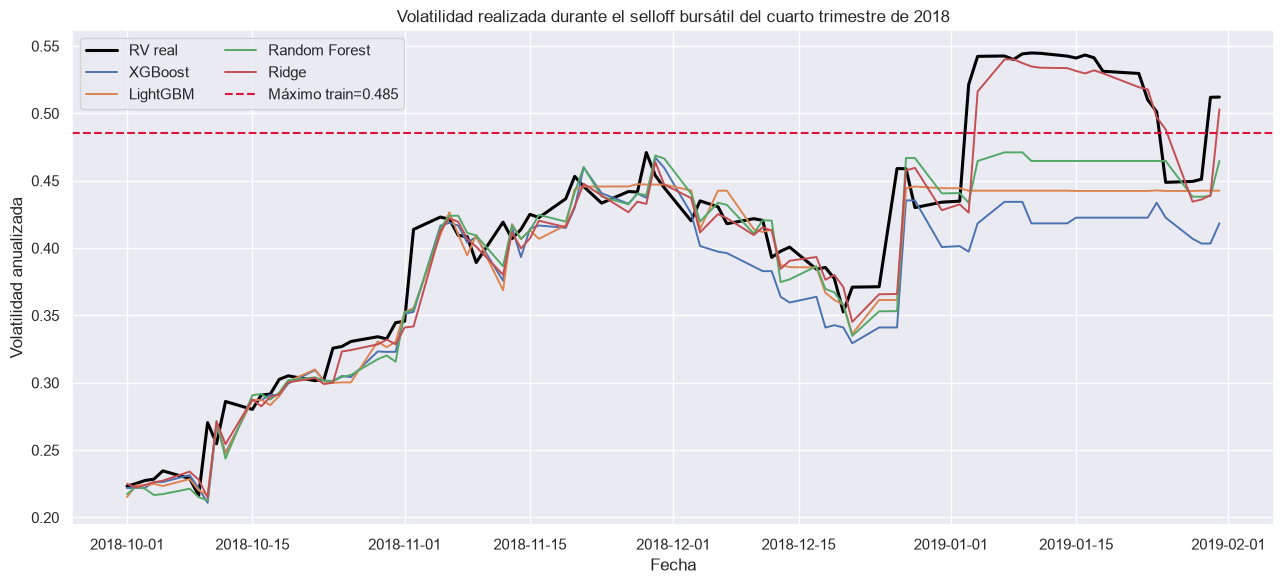

max(y_train): 0.4854
max(y_test): 0.5449


,modelo,max_pred,RMSE
0,XGBoost,0.4672,0.0563
1,LightGBM,0.4475,0.0451
2,Random Forest,0.4711,0.0379
3,Ridge,0.5401,0.0236


Predicciones de árboles acotadas por máximo de train: {'XGBoost': True, 'LightGBM': True, 'Random Forest': True}


In [9]:
CRISIS_START = pd.Timestamp("2018-10-01")
CRISIS_END = pd.Timestamp("2019-01-31")

rv20 = ret.rolling(20).std() * np.sqrt(252)
rv_data = pd.DataFrame(index=raw.index)
rv_data["rv_lag1"] = rv20.shift(1)
rv_data["rv_lag5"] = rv20.shift(5)
rv_data["rv_lag22"] = rv20.shift(22)
rv_data["rv_20"] = rv20
rv_data = rv_data.dropna()

rv_features = ["rv_lag1", "rv_lag5", "rv_lag22"]
rv_train = rv_data.loc[rv_data.index < CRISIS_START]
rv_test = rv_data.loc[(rv_data.index >= CRISIS_START) & (rv_data.index <= CRISIS_END)]

X_rv_train, y_rv_train = rv_train[rv_features], rv_train["rv_20"]
X_rv_test, y_rv_test = rv_test[rv_features], rv_test["rv_20"]

rv_models = {
    "XGBoost": xgb.XGBRegressor(
        n_estimators=300, learning_rate=0.05, max_depth=3,
        objective="reg:squarederror", random_state=RANDOM_STATE, n_jobs=-1
    ),
    "LightGBM": lgb.LGBMRegressor(
        n_estimators=300, learning_rate=0.05, num_leaves=15,
        verbosity=-1, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Random Forest": RandomForestRegressor(
        n_estimators=400, min_samples_leaf=3,
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Ridge": Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=1.0)),
    ]),
}

rv_predictions = {}
rv_rows = []
for model_name, model in rv_models.items():
    model.fit(X_rv_train, y_rv_train)
    prediction = model.predict(X_rv_test)
    rv_predictions[model_name] = prediction
    rv_rows.append({
        "modelo": model_name,
        "max_pred": float(np.max(prediction)),
        "RMSE": mean_squared_error(y_rv_test, prediction) ** 0.5,
    })

rv_metrics = pd.DataFrame(rv_rows)
max_train_rv = float(y_rv_train.max())
max_test_rv = float(y_rv_test.max())

fig, axis = plt.subplots(figsize=(13, 6))
axis.plot(y_rv_test.index, y_rv_test, color="black", lw=2.2, label="RV real")
for model_name, prediction in rv_predictions.items():
    axis.plot(y_rv_test.index, prediction, lw=1.4, label=model_name)
axis.axhline(max_train_rv, color="crimson", ls="--", label=f"Máximo train={max_train_rv:.3f}")
axis.set(title="Volatilidad realizada durante el selloff bursátil del cuarto trimestre de 2018", xlabel="Fecha", ylabel="Volatilidad anualizada")
axis.legend(ncol=2)
plt.tight_layout()
plt.show()

print(f"max(y_train): {max_train_rv:.4f}")
print(f"max(y_test): {max_test_rv:.4f}")
display(rv_metrics)

tree_names = ["XGBoost", "LightGBM", "Random Forest"]
tree_predictions_bounded = {
    name: bool(rv_metrics.set_index("modelo").loc[name, "max_pred"] <= max_train_rv + 1e-9)
    for name in tree_names
}
print("Predicciones de árboles acotadas por máximo de train:", tree_predictions_bounded)

### 4.2 — Costo de una Restricción Monótona Mal Especificada *(12 pts)*

En clase impusimos una restricción monótona **correcta** (`monotone_constraints=(1,)` para PD creciente en DTI). Esta parte te pide medir qué pasa cuando la restricción se especifica **incorrectamente** — un error de dirección plausible si un analista asume la relación equivocada.

**Requisitos:**
1. Reutiliza (o regenera) el escenario sintético PD vs DTI de la sesión 9 (relación creciente verdadera entre DTI y probabilidad de default)
2. Entrena tres versiones de `XGBClassifier` sobre los mismos datos: (a) **sin restricción**, (b) con restricción **correcta** `monotone_constraints=(1,)`, (c) con restricción **incorrecta** `monotone_constraints=(-1,)` (fuerza decreciente cuando la relación real es creciente)
3. Para cada una, calcula: el AUC en un set de test, y si la curva `P(default)` vs `DTI` es monótona (usa `np.diff(pred) >= -1e-9` como en clase)
4. Grafica las tres curvas de predicción vs DTI en un mismo panel
5. Cuantifica el costo: ¿cuánto AUC se pierde con la restricción incorrecta vs sin restricción y vs la correcta?

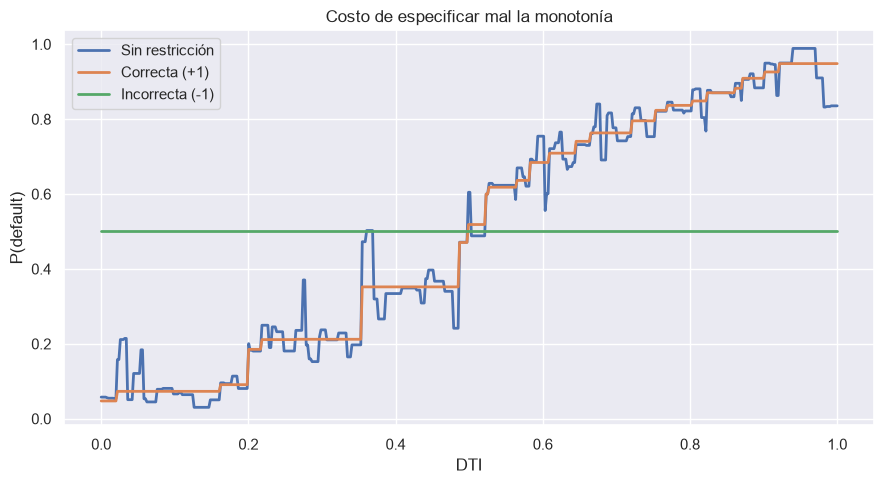

,AUC_test,monótona_creciente,monótona_decreciente
modelo,,,
Sin restricción,0.8334,False,False
Correcta (+1),0.8408,True,False
Incorrecta (-1),0.5000,True,True


Pérdida de AUC vs sin restricción: 0.3334
Pérdida de AUC vs restricción correcta: 0.3408


In [10]:
rng = np.random.default_rng(1)
n_mono = 2000
dti_mono = rng.uniform(0, 1, n_mono)
true_log_odds = -3.0 + 6.0 * dti_mono
default_probability = expit(true_log_odds)
default_mono = rng.binomial(1, default_probability)

X_mono = dti_mono.reshape(-1, 1)
X_mono_tr, X_mono_te, y_mono_tr, y_mono_te = train_test_split(
    X_mono, default_mono, test_size=0.30,
    stratify=default_mono, random_state=RANDOM_STATE
)

mono_models = {
    "Sin restricción": xgb.XGBClassifier(
        n_estimators=250, learning_rate=0.05, max_depth=3,
        eval_metric="auc", random_state=RANDOM_STATE
    ),
    "Correcta (+1)": xgb.XGBClassifier(
        n_estimators=250, learning_rate=0.05, max_depth=3,
        monotone_constraints=(1,), eval_metric="auc", random_state=RANDOM_STATE
    ),
    "Incorrecta (-1)": xgb.XGBClassifier(
        n_estimators=250, learning_rate=0.05, max_depth=3,
        monotone_constraints=(-1,), eval_metric="auc", random_state=RANDOM_STATE
    ),
}

dti_grid = np.linspace(0, 1, 500).reshape(-1, 1)
mono_rows = []
mono_curves = {}
for model_name, model in mono_models.items():
    model.fit(X_mono_tr, y_mono_tr)
    test_probability = model.predict_proba(X_mono_te)[:, 1]
    grid_probability = model.predict_proba(dti_grid)[:, 1]
    mono_curves[model_name] = grid_probability
    mono_rows.append({
        "modelo": model_name,
        "AUC_test": roc_auc_score(y_mono_te, test_probability),
        "monótona_creciente": bool(np.all(np.diff(grid_probability) >= -1e-9)),
        "monótona_decreciente": bool(np.all(np.diff(grid_probability) <= 1e-9)),
    })

mono_results = pd.DataFrame(mono_rows).set_index("modelo")
auc_unconstrained = mono_results.loc["Sin restricción", "AUC_test"]
auc_correct = mono_results.loc["Correcta (+1)", "AUC_test"]
auc_wrong = mono_results.loc["Incorrecta (-1)", "AUC_test"]
auc_cost_vs_unconstrained = auc_unconstrained - auc_wrong
auc_cost_vs_correct = auc_correct - auc_wrong

fig, axis = plt.subplots(figsize=(9, 5))
for model_name, probability in mono_curves.items():
    axis.plot(dti_grid.ravel(), probability, lw=2, label=model_name)
axis.set(title="Costo de especificar mal la monotonía", xlabel="DTI", ylabel="P(default)")
axis.legend()
plt.tight_layout()
plt.show()

display(mono_results)
print(f"Pérdida de AUC vs sin restricción: {auc_cost_vs_unconstrained:.4f}")
print(f"Pérdida de AUC vs restricción correcta: {auc_cost_vs_correct:.4f}")

### Preguntas de Interpretación — Parte 4

**a)** En el selloff de 2018, `max(train)` fue 0.4854 y `max(test)` 0.5449; los
máximos predichos fueron 0.4672 para XGBoost, 0.4475 para LightGBM y 0.4711 para
Random Forest. Los tres quedaron por debajo del máximo de train, mientras Ridge llegó
a 0.5401 y obtuvo el menor RMSE (0.0236), confirmando que el modelo lineal sí pudo
extrapolar fuera del rango observado.

**b)** La restricción incorrecta produjo AUC 0.5000 y perdió 0.3334 frente al modelo
sin restricción (AUC 0.8334) y 0.3408 frente a la restricción correcta (AUC 0.8408).
El costo es muy alto: imponer el signo opuesto eliminó prácticamente toda la capacidad
de ranking, mientras la restricción bien especificada mejoró ligeramente el modelo.

**c)** No impondría restricciones “por seguridad” sin validar antes el signo económico,
la evidencia empírica y la estabilidad temporal de cada relación. Una restricción bien
fundada puede mejorar interpretabilidad y robustez, pero una dirección errónea introduce
sesgo estructural y puede destruir capacidad discriminante, como muestra este experimento.

---
## Parte 5 — Bonus: Leaf-Wise vs Level-Wise, Cuantificando el Riesgo de Complejidad *(15 pts)*

### Contexto

La sesión 9 afirmó (en una tabla comparativa) que el crecimiento *leaf-wise* de LightGBM es más agresivo y sobreajusta más fácil que el crecimiento *level-wise* de XGBoost, y que `num_leaves` es el hiperparámetro de control de complejidad más importante en LightGBM. Esta parte te pide verificar esa afirmación empíricamente en vez de darla por cierta.

### 5.1 — Complejidad Real de los Árboles y Riesgo de Overfitting vs `num_leaves` *(10 pts)*

**Requisitos:**
1. Entrena un `XGBoost` (`max_depth=4`, `n_estimators=100`) y cuenta el número de hojas por árbol (usa `get_booster().trees_to_dataframe()` y cuenta nodos hoja por `Tree`)
2. Entrena cuatro `LightGBM` con `num_leaves ∈ {7, 15, 31, 63}` (mismo `n_estimators=100`, sin límite de profundidad) y cuenta también sus hojas reales por árbol
3. Grafica la distribución de hojas por árbol de XGBoost vs los 4 LightGBM (boxplot o histograma superpuesto)
4. Para los 4 LightGBM, calcula y grafica el **gap train-val de AUC** (`AUC_train - AUC_val`) vs `num_leaves` — debería crecer con `num_leaves`, mostrando cuantitativamente el riesgo de overfitting del crecimiento leaf-wise

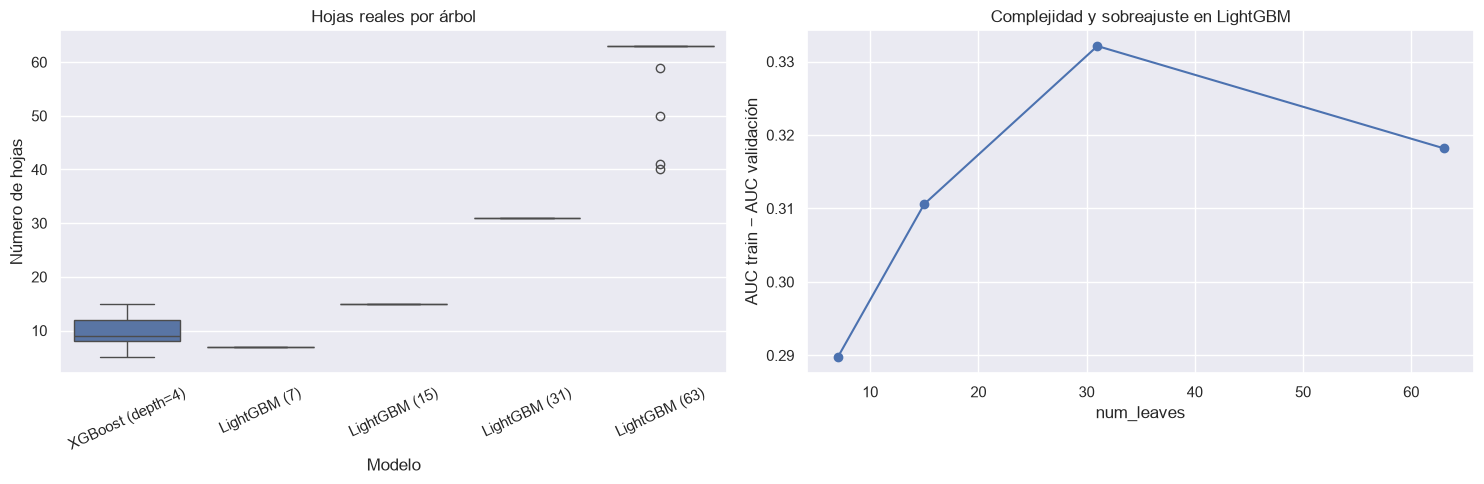

,mean,std,min,max
XGBoost (depth=4),9.5100,2.6534,5.0000,15.0000
LightGBM (7),7.0000,0.0000,7.0000,7.0000
LightGBM (15),15.0000,0.0000,15.0000,15.0000
LightGBM (31),31.0000,0.0000,31.0000,31.0000
LightGBM (63),62.3800,3.4224,40.0000,63.0000


,gap_train_val
7,0.2897
15,0.3106
31,0.3321
63,0.3182


In [11]:
xgb_leaves = xgb.XGBClassifier(
    n_estimators=100, max_depth=4, learning_rate=0.1,
    eval_metric="auc", random_state=RANDOM_STATE, n_jobs=-1
).fit(X_train, y_train)
xgb_trees_df = xgb_leaves.get_booster().trees_to_dataframe()
xgb_leaf_counts = (
    xgb_trees_df.loc[xgb_trees_df["Feature"] == "Leaf"]
    .groupby("Tree").size().reindex(range(100), fill_value=0)
)

leaf_counts_lgb = {}
gap_by_leaves = {}
for num_leaves in [7, 15, 31, 63]:
    model = lgb.LGBMClassifier(
        n_estimators=100, num_leaves=num_leaves, max_depth=-1,
        learning_rate=0.1, verbosity=-1,
        random_state=RANDOM_STATE, n_jobs=-1
    ).fit(X_train, y_train)
    tree_frame = model.booster_.trees_to_dataframe()
    counts = (
        tree_frame.loc[tree_frame["split_feature"].isna()]
        .groupby("tree_index").size().reindex(range(100), fill_value=0)
    )
    leaf_counts_lgb[num_leaves] = counts
    auc_train = roc_auc_score(y_train, model.predict_proba(X_train)[:, 1])
    auc_val = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])
    gap_by_leaves[num_leaves] = auc_train - auc_val

leaf_distribution = pd.DataFrame({"XGBoost (depth=4)": xgb_leaf_counts.to_numpy()})
for num_leaves, counts in leaf_counts_lgb.items():
    leaf_distribution[f"LightGBM ({num_leaves})"] = counts.to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=leaf_distribution, ax=axes[0])
axes[0].tick_params(axis="x", rotation=25)
axes[0].set(title="Hojas reales por árbol", xlabel="Modelo", ylabel="Número de hojas")

gap_series = pd.Series(gap_by_leaves, name="gap_train_val").sort_index()
axes[1].plot(gap_series.index, gap_series.values, marker="o")
axes[1].set(title="Complejidad y sobreajuste en LightGBM", xlabel="num_leaves", ylabel="AUC train − AUC validación")
plt.tight_layout()
plt.show()

display(leaf_distribution.describe().T[["mean", "std", "min", "max"]])
display(gap_series.to_frame())

### 5.2 — Preguntas de Interpretación

**a)** XGBoost produjo en promedio 9.51 hojas por árbol, frente a 15.00, 31.00 y
62.38 para LightGBM configurado con 15, 31 y 63 hojas, respectivamente. Por tanto,
los LightGBM de complejidad alta sí generan consistentemente más hojas y respaldan la
afirmación de que el crecimiento *leaf-wise* puede concentrar más complejidad.

**b)** El gap train-validación subió de 0.2897 con 7 hojas a 0.3106 con 15 y 0.3321
con 31; con 63 bajó a 0.3182, por lo que la relación no fue estrictamente monótona.
Para estos datos elegiría 15 hojas como máximo razonable: 31 amplía claramente el gap
y 63 añade mucha complejidad sin aportar evidencia de una mejor generalización.